## Experimentos - MLP MNIST

In [40]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from MLP import MLP

np.random.seed(42)

### Dados

In [41]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(-1, 784).astype(float) / 255
X_test  = X_test.reshape(-1, 784).astype(float)  / 255

def one_hot(y, n=10):
    oh = np.zeros((len(y), n))
    oh[np.arange(len(y)), y] = 1
    return oh

Y_train = one_hot(y_train)
Y_test  = one_hot(y_test)

idx = np.random.choice(len(X_train), 32000, replace=False)
X_train = X_train[idx]
Y_train = Y_train[idx]

print(f'Treino: {X_train.shape}  Teste: {X_test.shape}')

Treino: (32000, 784)  Teste: (10000, 784)


### Treinamento

In [42]:
def train(model, X_train, Y_train, X_val, Y_val, epochs=40, lr=0.1, batch_size=256):
    history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}
    N = X_train.shape[0]
    for epoch in range(epochs):
        idx = np.random.permutation(N)
        X_sh, Y_sh = X_train[idx], Y_train[idx]
        for start in range(0, N, batch_size):
            Xb = X_sh[start:start + batch_size]
            Yb = Y_sh[start:start + batch_size]
            model.forward(Xb)
            model.backward(Yb)
            model.update(lr)
        eval_idx = np.random.choice(N, 8000, replace=False)
        train_pred = model.forward(X_train[eval_idx])
        val_pred   = model.forward(X_val)
        history['loss'].append(model.loss(train_pred, Y_train[eval_idx]))
        history['acc'].append(model.accuracy(train_pred, Y_train[eval_idx]))
        history['val_loss'].append(model.loss(val_pred, Y_val))
        history['val_acc'].append(model.accuracy(val_pred, Y_val))
        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:3d} | loss: {history["loss"][-1]:.4f} | val_acc: {history["val_acc"][-1]*100:.2f}%')
    return history

## Experimentos

In [43]:
np.random.seed(42)
model_A = MLP([784, 64, 32, 10], activation='relu')
print('Config A — [784, 64, 32, 10] + ReLU + lr=0.1')
hist_A = train(model_A, X_train, Y_train, X_test, Y_test)

np.random.seed(42)
model_B = MLP([784, 64, 32, 10], activation='sigmoid')
print('\nConfig B — [784, 64, 32, 10] + Sigmoid + lr=0.1')
hist_B = train(model_B, X_train, Y_train, X_test, Y_test)

np.random.seed(42)
model_C = MLP([784, 64, 32, 10], activation='relu')
print('\nConfig C — [784, 64, 32, 10] + ReLU + lr=0.01')
hist_C = train(model_C, X_train, Y_train, X_test, Y_test, lr=0.01)

np.random.seed(42)
model_D = MLP([784, 64, 32, 10], activation='relu')
print('\nConfig D — [784, 64, 32, 10] + ReLU + lr=0.5')
hist_D = train(model_D, X_train, Y_train, X_test, Y_test, lr=0.5)

print('\n' + '='*55)
print(f'{"Configuração":<35} {"Acurácia Teste":>15}')
print('='*55)
print(f'{"A — ReLU 2 camadas (lr=0.1)":<35} {hist_A["val_acc"][-1]*100:>14.2f}%')
print(f'{"B — Sigmoid 2 camadas (lr=0.1)":<35} {hist_B["val_acc"][-1]*100:>14.2f}%')
print(f'{"C — ReLU 2 camadas (lr=0.01)":<35} {hist_C["val_acc"][-1]*100:>14.2f}%')
print(f'{"D — ReLU 2 camadas (lr=0.5)":<35} {hist_D["val_acc"][-1]*100:>14.2f}%')

Config A — [784, 64, 32, 10] + ReLU + lr=0.1
Epoch   5 | loss: 0.2001 | val_acc: 93.61%
Epoch  10 | loss: 0.1354 | val_acc: 95.19%
Epoch  15 | loss: 0.0966 | val_acc: 96.01%
Epoch  20 | loss: 0.0756 | val_acc: 96.23%
Epoch  25 | loss: 0.0635 | val_acc: 96.49%
Epoch  30 | loss: 0.0462 | val_acc: 96.83%
Epoch  35 | loss: 0.0426 | val_acc: 96.64%
Epoch  40 | loss: 0.0347 | val_acc: 96.73%

Config B — [784, 64, 32, 10] + Sigmoid + lr=0.1
Epoch   5 | loss: 0.8626 | val_acc: 81.78%
Epoch  10 | loss: 0.4821 | val_acc: 87.88%
Epoch  15 | loss: 0.3773 | val_acc: 89.72%
Epoch  20 | loss: 0.3272 | val_acc: 90.63%
Epoch  25 | loss: 0.3013 | val_acc: 91.44%
Epoch  30 | loss: 0.2775 | val_acc: 92.00%
Epoch  35 | loss: 0.2681 | val_acc: 92.39%
Epoch  40 | loss: 0.2542 | val_acc: 92.70%

Config C — [784, 64, 32, 10] + ReLU + lr=0.01
Epoch   5 | loss: 0.5102 | val_acc: 86.99%
Epoch  10 | loss: 0.3640 | val_acc: 90.21%
Epoch  15 | loss: 0.3063 | val_acc: 91.24%
Epoch  20 | loss: 0.2794 | val_acc: 91.93%

## Resultados

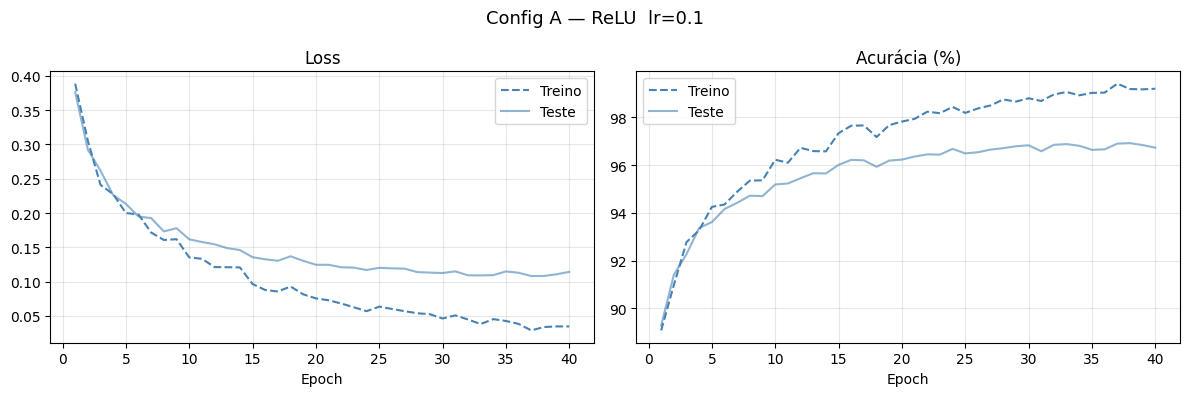

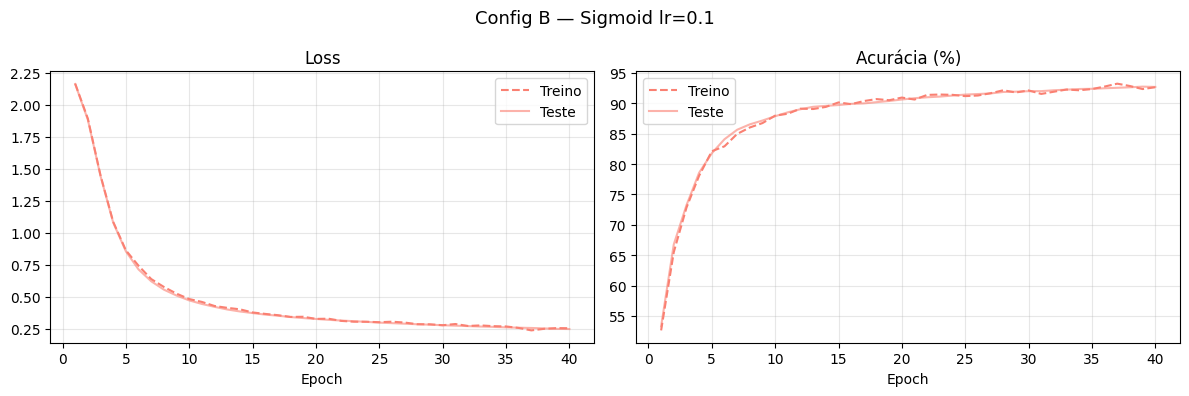

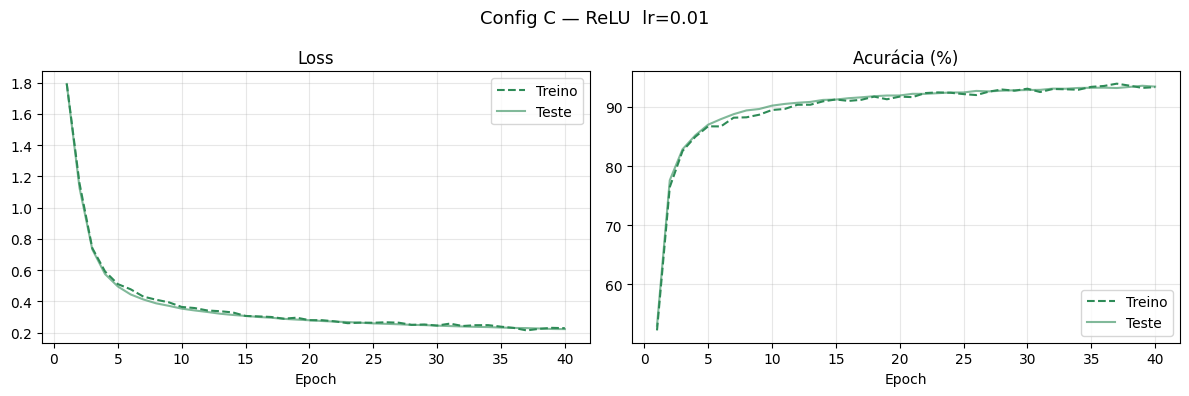

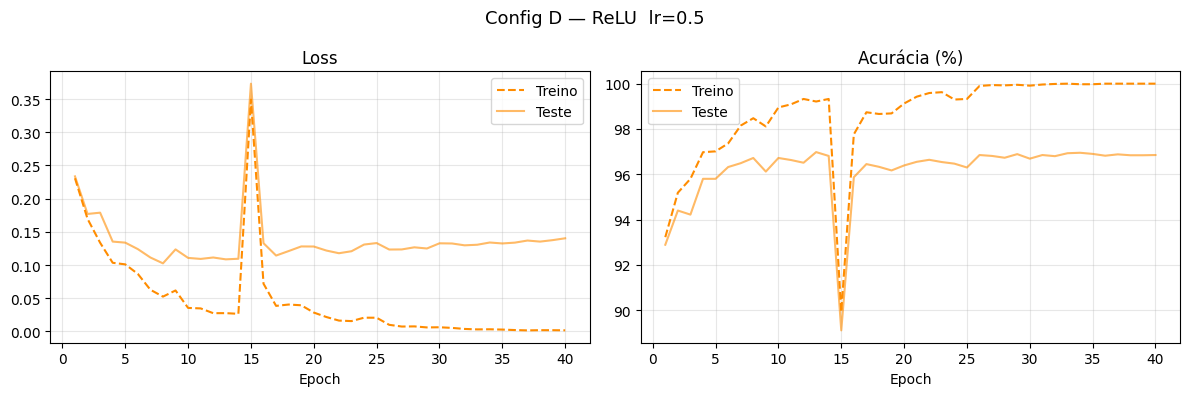

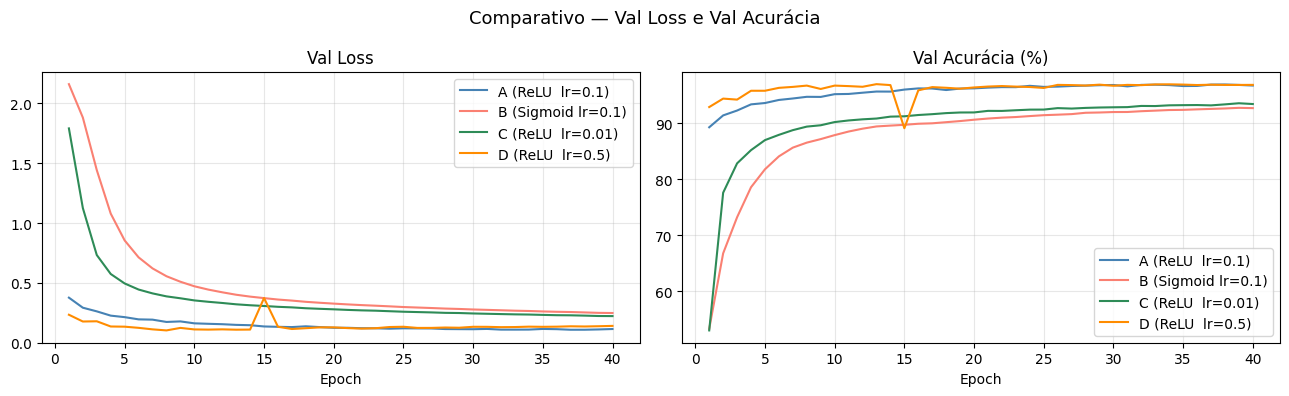

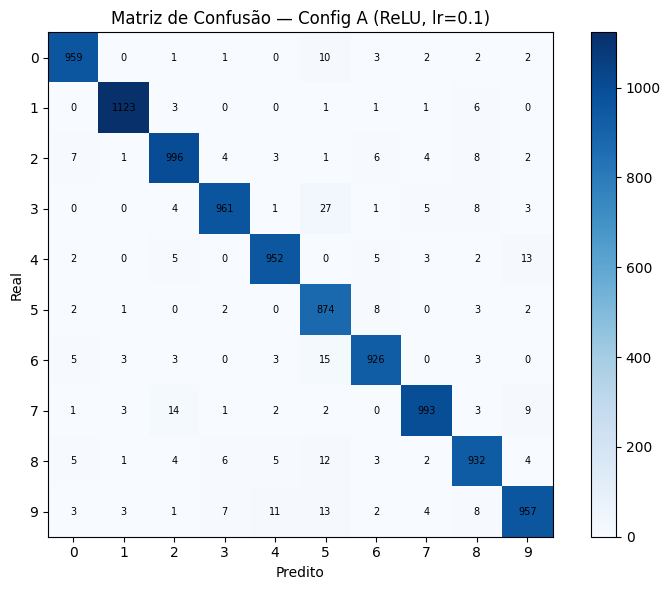

In [44]:
import os
os.makedirs('../resultados', exist_ok=True)

configs = [
    ('A', 'ReLU  lr=0.1',   hist_A, 'steelblue'),
    ('B', 'Sigmoid lr=0.1', hist_B, 'salmon'),
    ('C', 'ReLU  lr=0.01',  hist_C, 'seagreen'),
    ('D', 'ReLU  lr=0.5',   hist_D, 'darkorange'),
]

# --- gráfico individual por config ---
for label, title, hist, color in configs:
    epochs_range = range(1, len(hist["loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Config {label} — {title}", fontsize=13)

    axes[0].plot(epochs_range, hist["loss"],     "--", color=color, label="Treino")
    axes[0].plot(epochs_range, hist["val_loss"],       color=color, label="Teste", alpha=0.6)
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, [a*100 for a in hist["acc"]],     "--", color=color, label="Treino")
    axes[1].plot(epochs_range, [a*100 for a in hist["val_acc"]],       color=color, label="Teste", alpha=0.6)
    axes[1].set_title("Acurácia (%)"); axes[1].set_xlabel("Epoch")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"../resultados/config_{label.lower()}_curvas.png", dpi=120)
    plt.show()

# --- comparativo das 4 configs ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Comparativo — Val Loss e Val Acurácia", fontsize=13)
for label, title, hist, color in configs:
    epochs_range = range(1, len(hist["loss"]) + 1)
    axes[0].plot(epochs_range, hist["val_loss"],                  color=color, label=f"{label} ({title})")
    axes[1].plot(epochs_range, [a*100 for a in hist["val_acc"]], color=color, label=f"{label} ({title})")
axes[0].set_title("Val Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title("Val Acurácia (%)"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../resultados/comparativo_configs.png", dpi=120)
plt.show()

# --- matriz de confusão (Config A — melhor modelo) ---
test_pred   = model_A.forward(X_test)
pred_labels = np.argmax(test_pred, axis=1)
true_labels = np.argmax(Y_test,    axis=1)
cm = np.zeros((10, 10), dtype=int)
for t, p in zip(true_labels, pred_labels):
    cm[t, p] += 1
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("Predito"); ax.set_ylabel("Real")
ax.set_title("Matriz de Confusão — Config A (ReLU, lr=0.1)")
plt.tight_layout()
plt.savefig("../resultados/matriz_confusao.png", dpi=120)
plt.show()